In [1]:
import numpy as np
from matplotlib import pyplot as plt
import os
import random
import re
from scipy.stats import pearsonr
import nbimporter
import cepairsimplementation as ce
import exchangeabledatasetcreation as ex
import pandas as pd
import math

In [ ]:
t_data,_=ce.getTuebingen()

def create_folder(folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

folder_name="tuebingen"
create_folder(folder_name)

for i in range(len(t_data)):
    # Create a new plot
    plt.figure()
    plt.plot(t_data[i][0], t_data[i][1],'.')  # Example plot
    
    # Save the plot as a PNG file in the folder
    plt.savefig(f"{folder_name}/plot_{i+1}.png")
    plt.close()  # Close the plot to avoid overlapping in next iteration

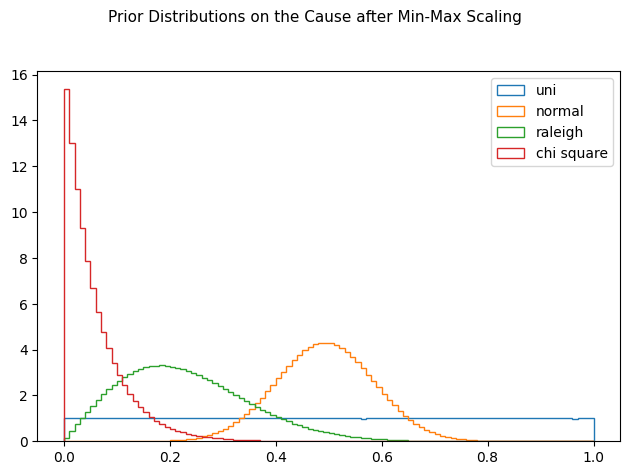

In [3]:
dists=["uni","normal","raleigh","chi square"]
fig = plt.figure()
for dist in dists:
    x=ex.sample_latent(10000000,dist)
    plt.hist(x,bins=100,histtype='step',density=True)
plt.legend(dists)

title="Prior Distributions on the Cause after Min-Max Scaling"
ce.save_imgs(fig,title,title,"interesting")

plt.show()

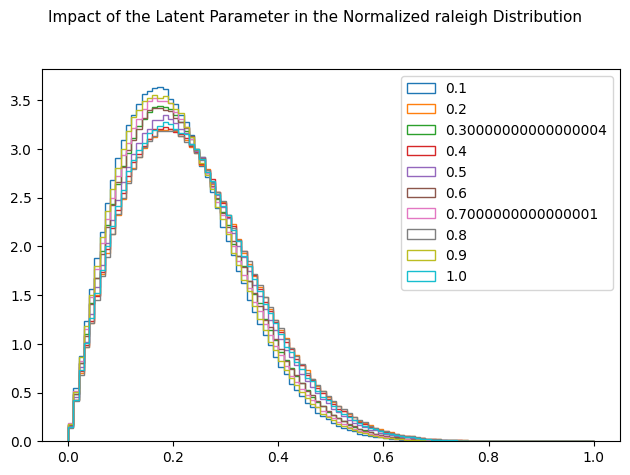

In [5]:
fig = plt.figure()
latent=np.linspace(0.1,1,10)
dist="raleigh"
for l in latent:
    x=ex.sample_latent(1000000,dist,l)
    plt.hist(x,bins=100,histtype='step',density=True)
plt.legend(latent)

title=f"Impact of the Latent Parameter in the Normalized {dist} Distribution"
ce.save_imgs(fig,title,title,"interesting")

plt.show()

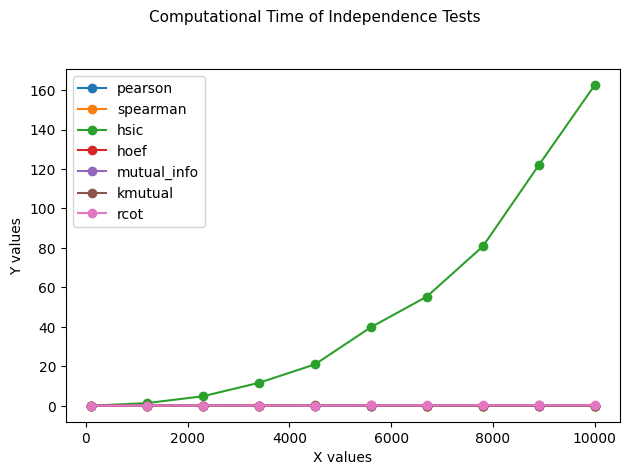

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Data
raw_data = """
pearson 100.0 0.002932310104370117
pearson 1200.0 0.0020689964294433594
pearson 2300.0 0.0014719963073730469
pearson 3400.0 0.0
pearson 4500.0 0.002805471420288086
pearson 5600.0 0.002009868621826172
pearson 6700.0 0.00286102294921875
pearson 7800.0 0.0011188983917236328
pearson 8900.0 0.0025107860565185547
pearson 10000.0 0.004047393798828125
spearman 100.0 0.0020096302032470703
spearman 1200.0 0.0020062923431396484
spearman 2300.0 0.0020074844360351562
spearman 3400.0 0.002007007598876953
spearman 4500.0 0.004872560501098633
spearman 5600.0 0.0030188560485839844
spearman 6700.0 0.002612590789794922
spearman 7800.0 0.003524303436279297
spearman 8900.0 0.00782012939453125
spearman 10000.0 0.005121469497680664
hsic 100.0 0.009572267532348633
hsic 1200.0 1.3133885860443115
hsic 2300.0 4.780590295791626
hsic 3400.0 11.596320629119873
hsic 4500.0 20.921830892562866
hsic 5600.0 39.77044343948364
hsic 6700.0 55.30392384529114
hsic 7800.0 80.75736808776855
hsic 8900.0 121.95848417282104
hsic 10000.0 162.54375958442688
hoef 100.0 0.040497541427612305
hoef 1200.0 0.014912128448486328
hoef 2300.0 0.009832620620727539
hoef 3400.0 0.018758773803710938
hoef 4500.0 0.016773223876953125
hoef 5600.0 0.020997047424316406
hoef 6700.0 0.025707483291625977
hoef 7800.0 0.03038620948791504
hoef 8900.0 0.028270244598388672
hoef 10000.0 0.014857292175292969
mutual_info 100.0 0.017998218536376953
mutual_info 1200.0 0.02651381492614746
mutual_info 2300.0 0.0
mutual_info 3400.0 0.0
mutual_info 4500.0 0.008823156356811523
mutual_info 5600.0 0.003498554229736328
mutual_info 6700.0 0.0024542808532714844
mutual_info 7800.0 0.0
mutual_info 8900.0 0.006925821304321289
mutual_info 10000.0 0.004149198532104492
kmutual 100.0 0.003395557403564453
kmutual 1200.0 0.02261829376220703
kmutual 2300.0 0.03979969024658203
kmutual 3400.0 0.05539083480834961
kmutual 4500.0 0.11259865760803223
kmutual 5600.0 0.11636877059936523
kmutual 6700.0 0.09227991104125977
kmutual 7800.0 0.054328203201293945
kmutual 8900.0 0.12370467185974121
kmutual 10000.0 0.07822012901306152
rcot 100.0 0.01564955711364746
rcot 1200.0 0.05845999717712402
rcot 2300.0 0.09329700469970703
rcot 3400.0 0.08066940307617188
rcot 4500.0 0.07436871528625488
rcot 5600.0 0.15932774543762207
rcot 6700.0 0.17729878425598145
rcot 7800.0 0.2041323184967041
rcot 8900.0 0.2163829803466797
rcot 10000.0 0.2038259506225586
"""

# Parse data
data = defaultdict(lambda: ([], []))
for line in raw_data.strip().split("\n"):
    label, x, y = line.split()
    data[label][0].append(float(x))
    data[label][1].append(float(y))

# Plot data
fig=plt.figure()
for label, (x_vals, y_vals) in data.items():
    plt.plot(x_vals, y_vals, marker='o', linestyle='-', label=label)

plt.xlabel("X values")
plt.ylabel("Y values")
title="Computational Time of Independence Tests"
plt.legend()
ce.save_imgs(fig,title,title,"interesting")
plt.show()


l 100.0 0.005054950714111328
l 1200.0 0.00559687614440918
l 2300.0 0.003228425979614258
l 3400.0 0.0
l 4500.0 0.0
l 5600.0 0.0
l 6700.0 0.008278369903564453
l 7800.0 0.004891395568847656
l 8900.0 0.0029392242431640625
l 10000.0 0.0033416748046875
gp 100.0 0.02647852897644043
gp 1200.0 0.5470724105834961
gp 2300.0 1.6571972370147705
gp 3400.0 3.5204102993011475
gp 4500.0 8.260806798934937
gp 5600.0 11.41300892829895
gp 6700.0 17.072779893875122
gp 7800.0 25.01646065711975
gp 8900.0 35.895402908325195
gp 10000.0 45.259721517562866


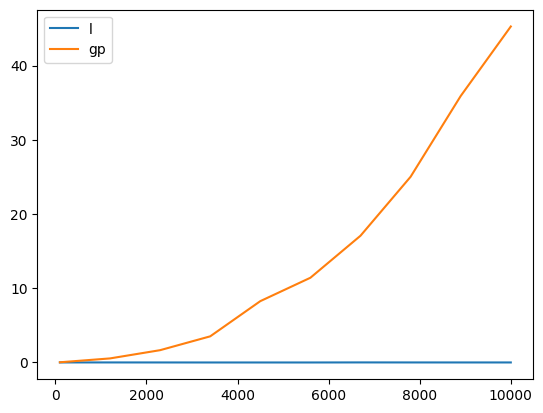

<Figure size 640x480 with 0 Axes>

In [6]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
models=["l","gp"]
lengths=np.linspace(100,10000,10)
fig=plt.figure()
for model in models:
    times=[]
    for l in lengths:
        x=np.linspace(-1,1,int(l))
        x=x.reshape(-1,1)
        y=x**2        
        start_time = time.time()  # start timing
        if model=="gp":
            gp = GaussianProcessRegressor().fit(x, y)
            y_predict = gp.predict(x)
        else:
            reg=LinearRegression().fit(x,y)
        elapsed_time = time.time() - start_time  # compute elapsed time
        times.append(elapsed_time)
        print(model,l,elapsed_time)
    plt.plot(lengths,times,label=model)
plt.legend()
plt.show()
title="Computational Time of Linear Regression and Gaussian Process"
ce.save_imgs(fig,title,title,"interesting")


                     pearson      spearman      hsic      hoef  mutual_info  \
x              -0.000000e+00 -0.000000e+00  1.000000  0.974672          inf   
random         -4.402842e-02 -3.190531e-02  0.041802  0.011107     0.020797   
uniform noise  -9.021721e-01 -9.204232e-01  0.008823 -0.005703     0.000077   
x with noise   -2.278841e-37 -1.328086e-38  0.658015  0.425729     0.836254   
x^2            -1.000000e+00 -8.970312e-01  0.416192  0.224992    -0.000000   
x^2 with noise -2.615505e-01 -2.703798e-01  0.144967  0.036978     0.006464   
+-x            -8.403459e-01 -8.400004e-01  0.243352  0.043369     0.000208   

                 kmutual          rcot    wasser  
x               3.094044 -7.148047e-16 -2.063482  
random          0.040560 -8.642931e-02 -2.548435  
uniform noise  -0.014230 -9.881158e-01 -1.357248  
x with noise    0.910220 -4.528228e-14 -2.087922  
x^2             1.497183 -1.898573e-09 -1.509519  
x^2 with noise  0.390414 -9.525385e-03 -1.658068  
+-x       

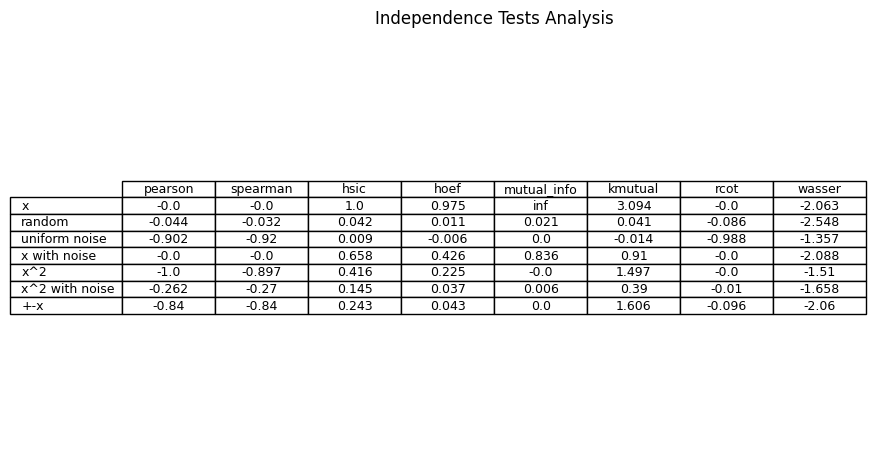

In [6]:
x=np.linspace(-1,1,100)
x=x.reshape(-1,1)
ys=[x,np.random.normal(0,1,len(x)),np.random.uniform(0,1,len(x)), x.flatten() + np.random.uniform(0,1,len(x)),x**2,(x**2).flatten()+ np.random.uniform(0,1,len(x)),np.sign(np.random.normal(0,1,len(x)))*x.flatten()]
y_titles=["x","random","uniform noise","x with noise","x^2","x^2 with noise","+-x"]
tests=["pearson","spearman","hsic","hoef","mutual_info","kmutual","rcot","wasser"]
results = []
# Loop over each y value and each test, calling test_independence
for y in ys:
    #plt.plot(x,y,'.')
    #plt.show()
    row = []
    for test in tests:
        result = ce.test_independence(x, y, method=test)
        row.append(result)
    results.append(row)

# Create a DataFrame for better visualization
df = pd.DataFrame(results, columns=tests, index=[f"{y_titles[i]}" for i in range(len(ys))])
print(df)
title="Independence Tests Analysis"
ce.save_table(df, title,title,"interesting")

pearson 100.0 0.000997304916381836
pearson 644.4444444444445 0.001188516616821289
pearson 1188.888888888889 0.0
pearson 1733.3333333333335 0.000997781753540039
pearson 2277.777777777778 0.0022013187408447266
pearson 2822.222222222222 0.0010209083557128906
pearson 3366.666666666667 0.0010089874267578125
pearson 3911.1111111111113 0.001016855239868164
pearson 4455.555555555556 0.0
pearson 5000.0 0.0010709762573242188
spearman 100.0 0.0010077953338623047
spearman 644.4444444444445 0.0012969970703125
spearman 1188.888888888889 0.0019516944885253906
spearman 1733.3333333333335 0.0
spearman 2277.777777777778 0.0
spearman 2822.222222222222 0.0
spearman 3366.666666666667 0.0
spearman 3911.1111111111113 0.0
spearman 4455.555555555556 0.0
spearman 5000.0 0.0
hsic 100.0 0.012395620346069336
hsic 644.4444444444445 0.10325837135314941
hsic 1188.888888888889 0.8201091289520264
hsic 1733.3333333333335 1.8614401817321777
hsic 2277.777777777778 4.517216920852661
hsic 2822.222222222222 5.898800849914551

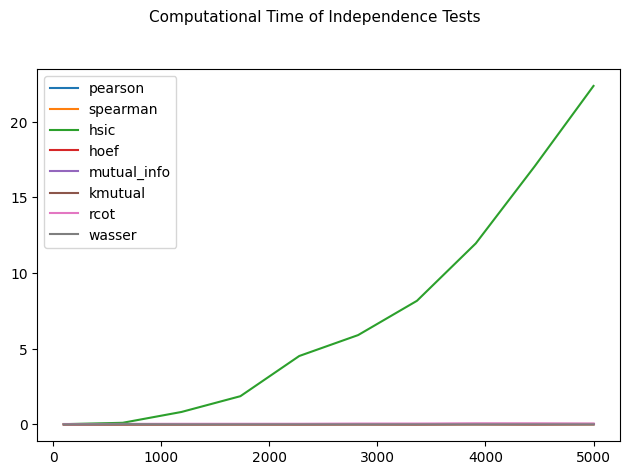

In [5]:
import time
lengths=np.linspace(100,5000,10)
tests=["pearson","spearman","hsic","hoef","mutual_info","kmutual","rcot","wasser"]
fig=plt.figure()
    
for test in tests:
    times=[]
    for l in lengths:
        x=np.linspace(-1,1,int(l))
        y=x**2        
        start_time = time.time()  # start timing
        result = ce.test_independence(x, y, method=test)
        elapsed_time = time.time() - start_time  # compute elapsed time
        times.append(elapsed_time)
        print(test,l,elapsed_time)
    plt.plot(lengths,times,label=test)
plt.legend()


title="Computational Time of Independence Tests"
ce.save_imgs(fig,title, title, "interesting")

plt.show()

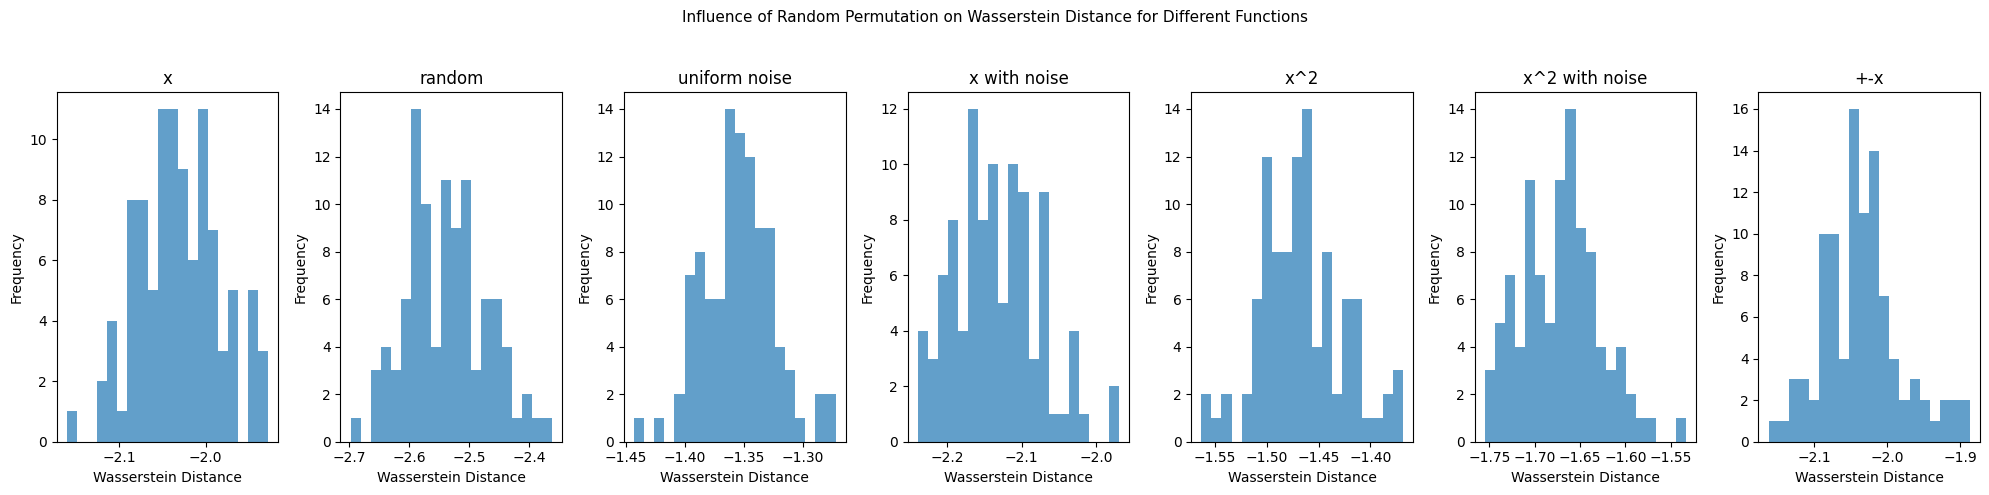

In [7]:
# Number of permutations
num_permutations = 100

# Initialize a dictionary to store results for each y
results_dict = {title: [] for title in y_titles}

# Perform the permutations and calculate the Wasserstein distance
for y, title in zip(ys, y_titles):
    for _ in range(num_permutations):
        result = ce.test_independence(x, y, method='wasser')
        results_dict[title].append(result)

# Plot histograms of the results
fig, axes = plt.subplots(1, len(y_titles), figsize=(20, 5), constrained_layout=True)
for ax, (title, results) in zip(axes, results_dict.items()):
    ax.hist(results, bins=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('Wasserstein Distance')
    ax.set_ylabel('Frequency')
title='Influence of Random Permutation on Wasserstein Distance for Different Functions'
ce.save_imgs(fig,title, title, "interesting")
plt.show()

In [9]:
import json
import math

# PART 1: Create and save the table with metric labels and decimal (0-1) values.
# The original values are percentages (e.g., 50.0 for 50%) so we convert them to decimals by dividing by 100.

# Define the table data with methods as rows and datasets as columns.
# Each value is a dict with keys "auroc" and "accuracy".
table_data = {
    "Best mse": {
        "CE-Cha": {"auroc": 50.0/100, "accuracy": 46.7/100},
        "CE-Net": {"auroc": 86.4/100, "accuracy": 76.7/100},
        "CE-Gauss": {"auroc": 18.7/100, "accuracy": 23.7/100},
        "CE-Multi": {"auroc": 46.9/100, "accuracy": 36.3/100},
        "CE-Tueb": {"auroc": 61.3/100, "accuracy": 61.7/100},
        "All": {"auroc": 61.3/100, "accuracy": 61.7/100},
    },
    "RECI": {
        "CE-Cha": {"auroc": 59.0/100, "accuracy": 56.0/100},
        "CE-Net": {"auroc": 66.0/100, "accuracy": 60.3/100},
        "CE-Gauss": {"auroc": 71.0/100, "accuracy": 64.3/100},
        "CE-Multi": {"auroc": 94.7/100, "accuracy": 85.3/100},
        "CE-Tueb": {"auroc": 70.5/100, "accuracy": 70.8/100},
        "All": {"auroc": 73.8/100, "accuracy": 66.7/100},
    },
    "LiNGAM": {
        "CE-Cha": {"auroc": 57.8/100, "accuracy": 55.7/100},
        "CE-Net": {"auroc": 3.3/100, "accuracy": 36.7/100},
        "CE-Gauss": {"auroc": 72.2/100, "accuracy": 77.3/100},
        "CE-Multi": {"auroc": 62.3/100, "accuracy": 63.3/100},
        "CE-Tueb": {"auroc": 31.1/100, "accuracy": 44.3/100},
        "All": {"auroc": 54.8/100, "accuracy": 57.8/100},
    },
    "IGCI": {
        "CE-Cha": {"auroc": 55.6/100, "accuracy": 55.0/100},
        "CE-Net": {"auroc": 57.4/100, "accuracy": 57.0/100},
        "CE-Gauss": {"auroc": 16.0/100, "accuracy": 21.3/100},
        "CE-Multi": {"auroc": 77.8/100, "accuracy": 68.0/100},
        "CE-Tueb": {"auroc": 63.1/100, "accuracy": 62.6/100},
        "All": {"auroc": 52.8/100, "accuracy": 50.7/100},
    },
    "ANM": {
        "CE-Cha": {"auroc": 43.7/100, "accuracy": 46.0/100},
        "CE-Net": {"auroc": 87.8/100, "accuracy": 78.0/100},
        "CE-Gauss": {"auroc": 90.7/100, "accuracy": 83.3/100},
        "CE-Multi": {"auroc": 25.5/100, "accuracy": 38.0/100},
        "CE-Tueb": {"auroc": 63.9/100, "accuracy": 62.7/100},
        "All": {"auroc": 60.7/100, "accuracy": 61.4/100},
    },
    "PNL": {
        "CE-Cha": {"auroc": 78.6/100, "accuracy": 76.0/100},
        "CE-Net": {"auroc": 75.6/100, "accuracy": 65.3/100},
        "CE-Gauss": {"auroc": 84.7/100, "accuracy": 78.3/100},
        "CE-Multi": {"auroc": 51.7/100, "accuracy": 56.3/100},
        "CE-Tueb": {"auroc": 73.8/100, "accuracy": 66.2/100},
        "All": {"auroc": 71.9/100, "accuracy": 68.9/100},
    },
    "GPI": {
        "CE-Cha": {"auroc": 71.5/100, "accuracy": 67.0/100},
        "CE-Net": {"auroc": 88.1/100, "accuracy": 79.0/100},
        "CE-Gauss": {"auroc": 90.2/100, "accuracy": 82.0/100},
        "CE-Multi": {"auroc": 73.8/100, "accuracy": 77.7/100},
        "CE-Tueb": {"auroc": 70.6/100, "accuracy": 62.5/100},
        "All": {"auroc": 79.9/100, "accuracy": 76.0/100},
    },
    "CGNN": {
        "CE-Cha": {"auroc": 76.2/100, "accuracy": 71.6/100},
        "CE-Net": {"auroc": 86.3/100, "accuracy": 75.3/100},
        "CE-Gauss": {"auroc": 89.3/100, "accuracy": 81.0/100},
        "CE-Multi": {"auroc": 94.7/100, "accuracy": 87.3/100},
        "CE-Tueb": {"auroc": 76.6/100, "accuracy": 75.9/100},
        "All": {"auroc": 86.5/100, "accuracy": 78.8/100},
    }
}

# Save the table data (with labels and decimal values) to a JSON file.
if not os.path.exists("data"):
    os.makedirs("data")
json_filename = "data/book_results.json"
with open(json_filename, "w") as f:
    json.dump(table_data, f, indent=4)
print(f"Table data saved to {json_filename}")


Table data saved to data/book_results.json


In [3]:
#add the columns of x and y directly in the excel file

def analyze_pair_files(directory="."):
    """
    Analyzes pair_des.txt files to extract source and destination variable information.

    Args:
        directory (str): Directory containing the pairXXXX_des.txt files.

    Returns:
        pandas.DataFrame with columns ["Pair File", "Source", "Destination"].
    """
    results = []

    if not os.path.isdir(directory):
        raise ValueError(f"Directory not found: {directory}")

    # Gather all matching files
    pair_files = sorted(
        f for f in os.listdir(directory)
        if re.match(r"pair\d{4}_des\.txt", f)
    )
    if not pair_files:
        print(f"No files matching 'pairXXXX_des.txt' found in '{directory}'")
        return pd.DataFrame(columns=["Pair File", "Source", "Destination"])

    # Regex for X --> Y or Y --> X
    arrow_re = re.compile(r"([xX])\s*-+>\s*([yY])|([yY])\s*-+>\s*([xX])")

    for filename in pair_files:
        filepath = os.path.join(directory, filename)
        x_var = y_var = source_var = dest_var = ground_truth_raw = ""

        try:
            # Read with UTF-8, fallback to Latin-1
            try:
                with open(filepath, 'r', encoding='utf-8') as f:
                    content = f.read()
            except UnicodeDecodeError:
                print(f"Attempting to decode {filename} with 'latin-1' due to UTF-8 error.")
                with open(filepath, 'r', encoding='latin-1') as f:
                    content = f.read()

            # --- Extract X and Y descriptions ---
            # Pattern to match "X (description):" or "X: description" or "X is description"
            # Prioritize content inside parentheses, then after colon, then after "is"
            
            # X variable extraction
            x_var_match = re.search(
                r"^\s*[xX](?:\s+column)?\s*(?:\(([^)]+)\))?\s*[:=]?\s*(.+?)?(?=\n|$)",
                content,
                re.MULTILINE
            )
            if x_var_match:
                # If content in parentheses is found, use that
                if x_var_match.group(1):
                    x_var = x_var_match.group(1).strip().rstrip('.')
                # Otherwise, if there's content after the colon/equals (group 2), use that
                elif x_var_match.group(2):
                    x_var = x_var_match.group(2).strip().rstrip('.')
            
            # Fallback to "X is" pattern if neither of the above captured anything
            if not x_var:
                x_match_is = re.search(
                    r"(?i)\b[xX]\s+is\s+(.+?)(?:\.|\n|$)",
                    content
                )
                if x_match_is:
                    x_var = x_match_is.group(1).strip().rstrip('.')


            # Y variable extraction (same logic as X)
            y_var_match = re.search(
                r"^\s*[yY](?:\s+column)?\s*(?:\(([^)]+)\))?\s*[:=]?\s*(.+?)?(?=\n|$)",
                content,
                re.MULTILINE
            )
            if y_var_match:
                if y_var_match.group(1):
                    y_var = y_var_match.group(1).strip().rstrip('.')
                elif y_var_match.group(2):
                    y_var = y_var_match.group(2).strip().rstrip('.')

            if not y_var:
                y_match_is = re.search(
                    r"(?i)\b[yY]\s+is\s+(.+?)(?:\.|\n|$)",
                    content
                )
                if y_match_is:
                    y_var = y_match_is.group(1).strip().rstrip('.')


            # --- Locate ground/group truth line and arrow ---
            lines = content.splitlines()
            norm = ""
            for i, line in enumerate(lines):
                if re.search(r"^\s*(?:ground|group)\s+truth", line, re.IGNORECASE):
                    m = arrow_re.search(line)
                    if m:
                        ground_truth_raw = m.group(0)
                    else:
                        for j in range(i+1, min(i+5, len(lines))):
                            m2 = arrow_re.search(lines[j])
                            if m2:
                                ground_truth_raw = m2.group(0)
                                break
                    break

            # Normalize arrow if found
            if ground_truth_raw:
                parts = arrow_re.search(ground_truth_raw)
                if parts:
                    if parts.group(1) and parts.group(2):
                        norm = "x-->y"
                    elif parts.group(3) and parts.group(4):
                        norm = "y-->x"

            # Fallback: always default to X --> Y if no arrow
            if not norm:
                norm = "x-->y"
                print(f"Info: No ground truth in {filename}; defaulting to X --> Y.")

            # Assign source/destination, with column-name fallbacks
            if norm == "x-->y":
                source_var = x_var if x_var else "First column"
                dest_var   = y_var if y_var else "Second column"
            elif norm == "y-->x":
                source_var = y_var if y_var else "Second column"
                dest_var   = x_var if x_var else "First column"
            else:
                print(f"Warning: Unparseable ground truth '{ground_truth_raw}' in {filename}. Defaulting to X --> Y.")
                source_var = x_var if x_var else "First column"
                dest_var   = y_var if y_var else "Second column"
            
            results.append({
                "Pair File": filename,
                "Source": source_var,
                "Destination": dest_var
            })

        except Exception as e:
            print(f"Error processing file {filename}: {e}")

    return pd.DataFrame(results)



output_excel_file = "../tuebingenpaper.xlsx"
pairs_dir="../Pairs"
analysis_df = analyze_pair_files(pairs_dir)
analysis_df.to_excel(output_excel_file, index=False)

Attempting to decode pair0072_des.txt with 'latin-1' due to UTF-8 error.
Info: No ground truth in pair0086_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0087_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0088_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0089_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0090_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0091_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0092_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0093_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0094_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0095_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0096_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0097_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0098_des.txt; defaulting to X --> Y.
Info: No ground truth in pair0106_des.txt; defaulting to X --> Y.
Inf

In [10]:
def linear(x, distpsi, angle, start_var, end_var):
    start_mean = 0
    end_mean = math.tan(angle)

    psi = ex.sample_latent(len(x), distpsi)
    psi1 = ex.rescale_distribution(psi, start_mean, start_var)
    psi2 = ex.rescale_distribution(psi, end_mean, end_var)

    y = ex.construct_linear(x, min(x), max(x), psi1, psi2)

    return y

def mix(x, distpsi, splits, vars, means):
    psi = ex.sample_latent(len(x), distpsi)

    psis = [ex.rescale_distribution(psi, means[0], vars[0])]
    y = []

    for j in range(len(splits) - 1):
        inds = (x >= splits[j]) & (x <= splits[j + 1])
        psis.append(ex.rescale_distribution(psi, means[j + 1], vars[j + 1]))
        y.extend(ex.construct_linear(x[inds], splits[j], splits[j + 1], psis[j][inds], psis[j + 1][inds]))
        print(y[-10:])
    print(psis[0][:10], psis[1][:10], psis[2][:10])
    return np.array(y)

def inv(x, distpsi, psi2_mean,psi_var):
    psi2 = ex.sample_latent(len(x), distpsi)
    psi2 = np.abs(ex.rescale_distribution(psi2, psi2_mean, psi_var))  # zero variance = constant

    y =  1 / (x + psi2)

    return y

[np.float64(0.7470307581723309), np.float64(0.7553070586399615), np.float64(0.6742828990479596), np.float64(0.7710072056553949), np.float64(0.7818072568322502), np.float64(0.8195365673730937), np.float64(0.9450208710320945), np.float64(0.8244093518472893), np.float64(0.8847661406069565), np.float64(0.9011495837001473)]
[np.float64(0.9054690653669848), np.float64(0.6496691089662763), np.float64(0.7717441964537292), np.float64(0.897347465420816), np.float64(1.0354537442844052), np.float64(1.0152932896732862), np.float64(1.0162607495395455), np.float64(0.8017397769954965), np.float64(0.98221010630936), np.float64(0.8159553475911765)]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] [0.83510618 0.95957011 0.92554008 0.84029856 0.92563539 0.98430555
 0.92060691 0.70912806 0.85542605 0.77861789] [0.83510618 0.95957011 0.92554008 0.84029856 0.92563539 0.98430555
 0.92060691 0.70912806 0.85542605 0.77861789]


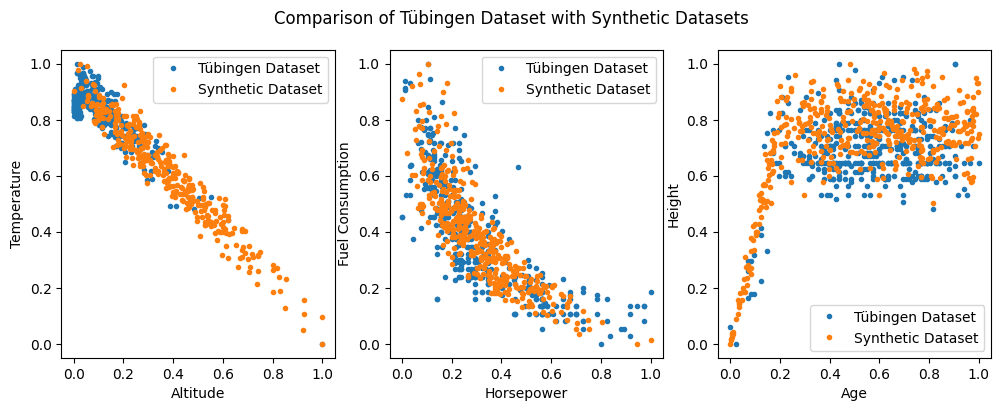

In [11]:
data,_= ce.getTuebingen()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
#temperature.
i=0
axes[0].plot(ex.minmax(data[i][0]), ex.minmax(data[i][1]), '.', label='Tübingen Dataset')
theta=ex.sample_latent(len(data[i][0]),'raleigh')
x=ex.minmax(theta)
#def linear(x, distpsi, angle, start_var, end_var, gamma_mean=0.3):
y=ex.minmax(linear(x, "normal", -0.8, 0.003, 0.003))
axes[0].plot(x, y, '.', label='Synthetic Dataset')
axes[0].set_xlabel('Altitude')
axes[0].set_ylabel('Temperature')
axes[0].legend()

#horsepower graph
i=13
axes[1].plot(ex.minmax(data[i][0]), ex.minmax(data[i][1]), '.', label='Tübingen Dataset')
theta=ex.sample_latent(len(data[i][0]),'raleigh')
x=ex.minmax(theta)
#def inv(x, distpsi, psi2_mean):
y=ex.minmax(inv(x, "normal", 0.5,0.006))
axes[1].plot(x, y, '.', label='Synthetic Dataset')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Fuel Consumption')
axes[1].legend()

#age vs height
i=21
axes[2].plot(ex.minmax(data[i][0]), ex.minmax(data[i][1]), '.', label='Tübingen Dataset')
theta=ex.sample_latent(len(data[i][0]),'uni')
x=ex.minmax(theta)
x=np.sort(x)
#def mix(x, distpsi, splits, vars, means)
y=ex.minmax(mix(x, "normal", [0,0.2,1], [0,0.01,0.01], [0,0.85,0.85]))
axes[2].plot(x, y, '.', label='Synthetic Dataset')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Height')
axes[2].legend()
plt.suptitle('Comparison of Tübingen Dataset with Synthetic Datasets')
plt.legend()